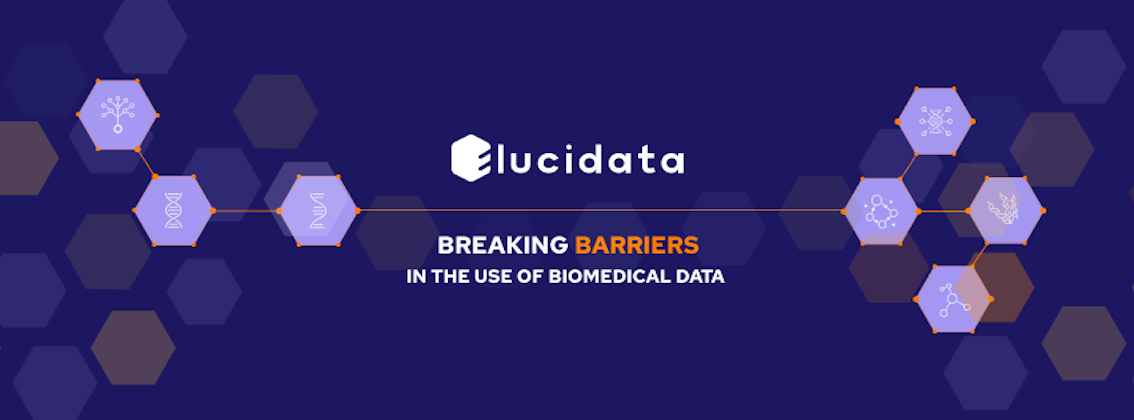

### Installations and Imports

In [ ]:
pip install polly-python==3.2.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 3.6 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.8/62.8 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.2/150.2 kB 5.1 MB/s eta 0:00:00
  Attempting uninstall: tabulate
    Found existing installation: tabulate 0.8.10
    Uninstalling tabulate-0.8.10:
      Successfully uninstalled tabulate-0.8.10
  Attempting uninstall: charset-normalizer
    Found existing installation: charset-normalizer 3.2.0
    Uninstalling charset-normalizer-3.2.0:
      Successfully uninstalled charset-normalizer-3.2.0
  Attempting uninstall: requests
    Found existing installation: requests 2.31.0
    Uninstalling requests-2.31.0:
      Successfully uninstalled requests-2.31.0
  Attempting uninstall: polly-python
    Found existing installation: polly-python 1.0.0


    Uninstalling polly-python-1.0.0:
      Successfully uninstalled polly-python-1.0.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
polly-validator 0.0.2 requires requests==2.25.1, but you have requests 2.28.1 which is incompatible.
polly-validator 0.0.2 requires tabulate==0.8.10, but you have tabulate 0.9.0 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


In [4]:
#Imports

from polly.auth import Polly
from polly.polly_kg import PollyKG

import pandas as pd
import numpy as np
import sys
import io

import networkx as nx
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [ ]:
#Authentication

AUTH_KEY = "auth_key"
Polly.auth(AUTH_KEY)

You're currently using an outdated version of polly-python '1.0.0'. Please update using the command 'pip install polly-python==3.1.0' to upgrade to the newest version '3.1.0'


In [6]:
#Connect to PollyKG

kg = PollyKG()

In [ ]:
# Get engine status
kg.get_engine_status()

{'status': 'healthy', 'gremlin': {'version': 'tinkerpop-3.7.1'}, 'opencypher': {'version': 'Neptune-9.0.20190305-1.0'}}


{'status': 'healthy',
 'gremlin': {'version': 'tinkerpop-3.7.1'},
 'opencypher': {'version': 'Neptune-9.0.20190305-1.0'}}

### PollyKG Summary

In [7]:
#Get graph summary

res1 = kg.get_graph_summary()#get graph summary
res1 = pd.json_normalize(res1)
res1

{'numNodes': 426515, 'numEdges': 9750778, 'numNodeLabels': 7, 'numEdgeLabels': 27, 'nodeLabels': ['Drug', 'Phenotype', 'Gene', 'Disease', 'Pathway', 'Go', 'Protein'], 'edgeLabels': ['is_a_phenotype', 'disease_has_feature_disease', 'predisposes_towards_disease', 'has_characteristic_disease', 'has_part_go', 'targets', 'linked_to_pathway', 'happens_during_go', 'excluded_subClassOf_disease', 'part_of_go', 'mim2gene_medgen_disease', 'ends_during_go', 'is_a_pathway', 'linked_to', 'positively_regulates_go', 'part_of_progression_of_disease_disease', 'regulates_go', 'disease_arises_from_feature_disease', 'occurs_in_go', 'is_a_go', 'negatively_regulates_go', 'disease_has_major_feature_disease', 'intersection_of_disease', 'curated_content_resource_disease', 'disease_shares_features_of_disease', 'is_a_disease', 'interacts_with'], 'numNodeProperties': 48, 'numEdgeProperties': 28, 'nodeProperties': [{'description': 219818}, {'LocusTag': 193500}, {'Symbol': 193500}, {'Synonyms': 193500}, {'tax_id': 1

,numNodes,numEdges,numNodeLabels,numEdgeLabels,nodeLabels,edgeLabels,numNodeProperties,numEdgeProperties,nodeProperties,edgeProperties,totalNodePropertyValues,totalEdgePropertyValues
0,426515,9750778,7,27,"[Drug, Phenotype, Gene, Disease, Pathway, Go, ...","[is_a_phenotype, disease_has_feature_disease, ...",48,28,"[{'description': 219818}, {'LocusTag': 193500}...","[{'count': 7230614}, {'intA': 7230614}, {'intA...",3479555,62400221


In [8]:
#Node types

res1[['nodeLabels']].explode('nodeLabels')

,nodeLabels
0,Drug
0,Phenotype
0,Gene
0,Disease
0,Pathway
0,Go
0,Protein


In [9]:
#Edge Types

res1[['edgeLabels']].explode('edgeLabels')

,edgeLabels
0,is_a_phenotype
0,disease_has_feature_disease
0,predisposes_towards_disease
0,has_characteristic_disease
0,has_part_go
0,targets
0,linked_to_pathway
0,happens_during_go
0,excluded_subClassOf_disease
0,part_of_go


### Querying  PollyKG

##### Two Query Languages Available
- Gremlin Query Language
- openCypher Query Language

In [ ]:
#Find all Node Types  - openCypher

res2 = kg.run_opencypher_query("""MATCH (n)
                               RETURN labels(n) AS NodeType, count(n) AS NodeCount
                               ORDER BY NodeCount DESC;""")
pd.json_normalize(res2)

,NodeType,NodeCount
0,[Gene],193500
1,[Protein],109248
2,[Go],47995
3,[Disease],29967
4,[Pathway],22608
5,[Phenotype],19483
6,[Drug],3714


In [12]:
#Find all Node Types  - Gremlin

res2 = kg.run_gremlin_query("g.V().groupCount().by(label).order(local).by(values, desc)")

node = []
count = []
for i in range(0,len(res2['data']['@value'][0]['@value'])):
    if (i+1)%2 == 0:
        count.append(res2['data']['@value'][0]['@value'][i]['@value'])
    else:
        node.append(res2['data']['@value'][0]['@value'][i])
res2 = pd.DataFrame({'NodeType':node,'NodeCount':count})
res2

,NodeType,NodeCount
0,Gene,193500
1,Protein,109248
2,Go,47995
3,Disease,29967
4,Pathway,22608
5,Phenotype,19483
6,Drug,3714


In [13]:
#Find all Edge Types - Gremlin

res3 = kg.run_gremlin_query("""g.E().groupCount().by(label).order(local).by(values, desc)""")

edge = []
count = []
for i in range(0,len(res3['data']['@value'][0]['@value'])):
    if (i+1)%2 == 0:
        count.append(res3['data']['@value'][0]['@value'][i]['@value'])
    else:
        edge.append(res3['data']['@value'][0]['@value'][i])

res3 = pd.DataFrame({'EdgeType':edge,'EdgeCount':count})
res3        

,EdgeType,EdgeCount
0,interacts_with,7327447
1,targets,1931724
2,linked_to,292852
3,encodes,105924
4,has_phenotype,102425
5,linked_to_pathway,46818
6,is_a_go,40264
7,is_a_disease,39098
8,has_indication,36066
9,is_a_pathway,22746


In [15]:
#Find the Node Types that an Edge Connects - Gremlin

res4 = kg.run_gremlin_query("""g.E().hasLabel('interacts_with')
                               .limit(10000)
                               .project('From_Node_Type', 'To_Node_Type')
                               .by(outV().label())  
                               .by(inV().label())  
                               .dedup()""")
res4

{'data': {'@type': 'g:List',
  '@value': [{'@type': 'g:Map',
    '@value': ['To_Node_Type', 'Gene', 'From_Node_Type', 'Gene']}]},
 'meta': {'@type': 'g:Map', '@value': []}}

In [17]:
#Properties of a Node - Gremlin

res5 = kg.run_gremlin_query("g.V().hasLabel('Gene').properties().key().dedup()")
res5

{'data': {'@type': 'g:List',
  '@value': ['EnsemblGeneID',
   'Symbol',
   'LocusTag',
   'Synonyms',
   'dbXrefs',
   'chromosome',
   'map_location',
   'description',
   'type_of_gene',
   'Symbol_from_nomenclature_authority',
   'Nomenclature_status',
   'Modification_date',
   'Feature_type',
   'tax_id']},
 'meta': {'@type': 'g:Map', '@value': []}}

In [ ]:
#Properties of a Node - openCypher

res5 = kg.run_opencypher_query("""MATCH (n:Gene)
                               RETURN keys(n) AS properties
                               LIMIT 1;""")
res5

[{'properties': ['Symbol',
   'tax_id',
   'dbXrefs',
   'LocusTag',
   'Synonyms',
   'chromosome',
   'description',
   'Feature_type',
   'map_location',
   'type_of_gene',
   'EnsemblGeneID',
   'Modification_date',
   'Nomenclature_status',
   'Symbol_from_nomenclature_authority']}]